In [92]:
#-----------------------------------#
# SETTING UP YOUR WORKSPACE #
# ----------------------------------#

# Feel free to add or delete
import os
import sys
import warnings
import numpy as np
import pandas as pd
import pyfixest as pf
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats
from typing import List
from stargazer.stargazer import Stargazer
from IPython.display import display, Latex, HTML
from sklearn.metrics import mean_squared_error, r2_score, log_loss

warnings.filterwarnings("ignore") 

data = pd.read_csv("https://osf.io/jvgrf/download")

#-----------------------------------------------------------#
# Sample Selection and Cleaning                             #
# ----------------------------------------------------------#

data["ageyoungestchild"] = np.where(
    data["children"] == 0, None, data["ageyoungestchild"]
)
data["ageyoungestchild"] = pd.to_numeric(data["ageyoungestchild"])
data["ordertaker"] = data["ordertaker"].astype(int)

data = data.drop(columns=["phonecalls0"])

# PART I

## 1.1

In [65]:
data.groupby('treatment')['age'].mean()

treatment
0    24.347458
1    24.435115
Name: age, dtype: float64

In [66]:
model = smf.ols("age ~ treatment", data=data, cov_type='HC1').fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    age   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                   0.03780
Date:                Tue, 17 Feb 2026   Prob (F-statistic):              0.846
Time:                        18:19:36   Log-Likelihood:                -667.95
No. Observations:                 249   AIC:                             1340.
Df Residuals:                     247   BIC:                             1347.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     24.3475      0.327     74.452      0.0

Yes, they are the same

## 1.2

In [67]:
data = data.replace({"yes": 1, "no": 0})

In [68]:
vars_to_balance = data.columns[~data.columns.isin(
    ["index", "personid", "treatment", 
     "perform11", "quitjob", "phonecalls1",
     "type"])].to_list()

def star_from_p(p):
    if p < 0.01:
        return "***"
    if p < 0.05:
        return "**"
    if p < 0.10:
        return "*"
    return ""

def balance_table(df, group_col, variables, decimals=3):
    rows = []

    # split groups
    g0 = df[df[group_col] == 0]
    g1 = df[df[group_col] == 1]

    for v in variables:
        x0 = pd.to_numeric(g0[v], errors="coerce").dropna()
        x1 = pd.to_numeric(g1[v], errors="coerce").dropna()

        mean0, mean1 = x0.mean(), x1.mean()
        sd0, sd1 = x0.std(ddof=1), x1.std(ddof=1)
        n0, n1 = x0.shape[0], x1.shape[0]

        # Welch's t-test (robust to unequal variances)
        tstat, pval = stats.ttest_ind(x1, x0, equal_var=False, nan_policy="omit")

        diff = mean1 - mean0
        stars = star_from_p(pval)

        rows.append({
            "Variable": v,
            "Control mean (sd)": f"{mean0:.{decimals}f} ({sd0:.{decimals}f})",
            "Treated mean (sd)": f"{mean1:.{decimals}f} ({sd1:.{decimals}f})",
            "Diff (T-C)": f"{diff:.{decimals}f}{stars}",
            "p-value": round(pval, decimals)
        })

    out = pd.DataFrame(rows)
    return out

# Now I can use my function and input the data in. 
bt = balance_table(data, "treatment", vars_to_balance, decimals=3)

# Print nicely (console)
print("\nBALANCE TABLE (Control vs Treated)")
print(bt.to_string(index=False))


BALANCE TABLE (Control vs Treated)
          Variable  Control mean (sd)  Treated mean (sd) Diff (T-C)  p-value
        ordertaker      0.559 (0.499)      0.519 (0.502)     -0.040    0.527
         perform10     -0.040 (0.540)     -0.028 (0.619)      0.012    0.874
  prior_experience    16.753 (23.818)    18.962 (27.658)      2.209    0.499
               age     24.347 (3.536)     24.435 (3.567)      0.088    0.846
            tenure    28.254 (21.938)    26.137 (21.942)     -2.117    0.448
          basewage 1562.799 (185.397) 1539.864 (136.157)    -22.935    0.272
             bonus 1092.587 (655.717) 1030.902 (597.664)    -61.685    0.440
         grosswage 3003.362 (825.599) 2949.730 (758.050)    -53.632    0.595
  ageyoungestchild      0.712 (1.922)      0.527 (1.939)     -0.185    0.450
     costofcommute      8.338 (5.554)      7.892 (8.031)     -0.446    0.608
          children      0.237 (0.427)      0.115 (0.320)   -0.123**    0.012
            rental      0.203 (0.404)   

## 1.3

Besides the variable married which shows the difference to be significant to * and the children variable which shows the difference to be significant to **, the two groups do not seem to be different.

# PART II

## 2.1

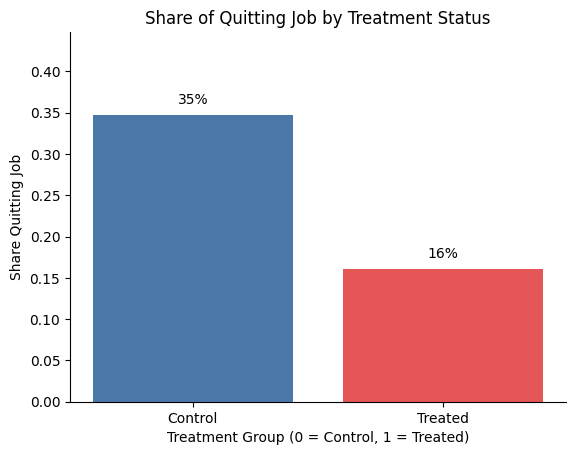

In [70]:
quit_summary = (
    data.groupby("treatment", as_index=False)["quitjob"]
        .mean()
        .rename(columns={"quitjob": "share_quitjob"})
)

# Ensure order Control then Treated
order = [0, 1]
quit_summary["treatment"] = pd.Categorical(quit_summary["treatment"], categories=order, ordered=True)
quit_summary = quit_summary.sort_values("treatment").reset_index(drop=True)
quit_summary["treat_label"] = quit_summary["treatment"].map({0: "Control", 1: "Treated"})

# Plot
colors = {"Control": "#4C78A8", "Treated": "#E45756"}

fig, ax = plt.subplots()

bars = ax.bar(
    quit_summary["treat_label"].astype(str),
    quit_summary["share_quitjob"],
    color=[colors[g] for g in quit_summary["treat_label"].astype(str)]
)

# If you want to get fancy, sdd labels above bars (percent)
for b, val in zip(bars, quit_summary["share_quitjob"]):
    ax.text(
        b.get_x() + b.get_width() / 2,
        val + 0.01,
        f"{val:.0%}",
        ha="center",
        va="bottom"
    )

ax.set_xlabel("Treatment Group (0 = Control, 1 = Treated)")
ax.set_ylabel("Share Quitting Job")
ax.set_title("Share of Quitting Job by Treatment Status")

# Make it look clean (similar to theme_minimal)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.ylim(0, max(quit_summary["share_quitjob"]) + 0.10)
plt.show()

## 2.2

It seems that workers who have gone through the treatment of working from home have a 19 percentage points lower chances of quitting compared to workers who stayed in office.

# PART III

## 3.1

In [78]:
model1 = smf.ols("quitjob ~ treatment", data=data, cov_type='HC1').fit()
model2 = smf.ols("phonecalls1 ~ treatment", data=data[data['ordertaker']==1], cov_type='HC1').fit()
model3 = smf.ols("quitjob ~ treatment + married + children", data=data, cov_type='HC1').fit()
model4 = smf.ols("phonecalls1 ~ treatment + married + children", data=data[data['ordertaker']==1], cov_type='HC1').fit()

stargazer = Stargazer([model1, model2, model3, model4])
stargazer.title("Regression results")
stargazer.custom_columns(["Model 1 (quit)", "Model 2 (calls)", "Model 3 (quit)", "Model 4 (calls)"], [1, 1, 1, 1])
stargazer.covariate_order(['treatment', 'married', 'children', 'Intercept'])
display(HTML(stargazer.render_html()))

## 3.2

**Model 1**: The predicted average decrease in the chances of quitting are 18.7% for workers who worked from home compared to those who did not (significant to p<0.01).

**Model 2**: The predicted average increase in the number of phone calls made is 4.039 for phone workers who worked from home compared to those who did not (significant to p<0.01).

**Model 3**: The predicted average decrease in the chances of quitting are 18.7% for workers who worked from home compared to those who did not (significant to p<0.01) (holding marriage and children constant). The effects of marriage or children on chances of quitting are not significant.

**Model 4**: The predicted average increase in the number of phone calls made is 4.056 for phone workers who worked from home compared to those who did not (significant to p<0.01) (holding marriage and children constant). The predicted average decrease in the number of phone calls is 5.439 for married phone workers compared to unmarried ones (significant to p<0.01) (holding treatment and children constant). Finally, the predicted average increase in the number of phone calls made is 3.872 for phone workers with kids compared to those without kids (significant to p<0.1) (holding marriage and treatment constant).

In [80]:
model1 = smf.ols("quitjob ~ treatment", data=data, cov_type='HC1').fit()
model2 = smf.ols("phonecalls1 ~ treatment", data=data[data['ordertaker']==1], cov_type='HC1').fit()
model3 = smf.ols("quitjob ~ treatment + " + " + ".join(vars_to_balance), data=data, cov_type='HC1').fit()
model4 = smf.ols("phonecalls1 ~ treatment + " + " + ".join(vars_to_balance), data=data[data['ordertaker']==1], cov_type='HC1').fit()

stargazer = Stargazer([model1, model2, model3, model4])
stargazer.title("Regression results")
stargazer.custom_columns(["Model 1 (quit)", "Model 2 (calls)", "Model 3 (quit)", "Model 4 (calls)"], [1, 1, 1, 1])
stargazer.covariate_order(['treatment'] + vars_to_balance + ['Intercept'])
display(HTML(stargazer.render_html()))

Yes, it changes the results.

## 3.3

In [83]:
data.head().style

,index,personid,treatment,ordertaker,type,quitjob,phonecalls1,perform10,perform11,prior_experience,age,tenure,basewage,bonus,grosswage,ageyoungestchild,costofcommute,children,rental,bedroom,male,married,second_technical,high_school,tertiary_technical,university,internet
0,141,3906,1,0,notification group (airfare),0.000000,0.000000,0.084573,0.308620,84.000000,33.000000,96.000000,1883.333400,713.444460,2737.546600,10,8.000000,1,0,1,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000
1,138,4122,1,1,phone call group,0.000000,21.797000,0.000450,0.700559,0.000000,30.000000,94.000000,1700.000000,2097.222200,4096.245600,0,18.000000,0,0,0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
2,110,4448,0,0,notification group (airfare),0.000000,0.000000,0.455910,0.488662,0.000000,35.000000,92.000000,1750.000000,2153.333300,4269.296400,11,10.000000,1,0,1,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000
3,242,4942,1,0,post-order group (hotel),0.000000,0.000000,0.918510,-0.275367,0.000000,27.000000,82.000000,1900.000000,3043.000000,5295.395500,0,20.000000,0,0,1,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
4,147,5018,1,0,post-order group (hotel),0.000000,0.000000,-0.377443,-0.606368,0.000000,29.000000,82.000000,2138.889000,464.333340,1387.590000,0,15.000000,1,0,1,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000


In [ ]:
model5 = smf.ols("quitjob ~ treatment + age + male + costofcommute", data=data, cov_type='HC1').fit()
model6 = smf.probit("quitjob ~ treatment + age + male + costofcommute", data=data, cov_type='HC1').fit()
model7 = smf.probit("quitjob ~ treatment + age + male + costofcommute", data=data, cov_type='HC1').fit()

mfx6 = model6.get_margeff(at="overall")
mfx6_res = mfx6.summary_frame()

model7.params.update(mfx6_res["dy/dx"])
model7.bse.update(mfx6_res["Std. Err."])

stargazer1 = Stargazer([model5, model6, model7])
stargazer1.title("OLS vs Probit vs Probit with Marginal Effects")
stargazer1.custom_columns(["Model 5 (OLS)", "Model 6 (Probit)", "Model 7 (Probit MFX)"], [1, 1, 1])
stargazer1.covariate_order(['treatment', 'age', 'male', 'costofcommute', 'Intercept'])
display(HTML(stargazer1.render_html()))

Optimization terminated successfully.
         Current function value: 0.510232
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.510232
         Iterations 6


In [93]:
data['pred_lpm'] = model5.predict(
    data.loc[:,['treatment','age','male','costofcommute']])

data['pred_probit'] = model6.predict(
    data.loc[:,['treatment','age','male','costofcommute']])

preds = {
    "LPM": data["pred_lpm"].astype(float),
    "Probit": data["pred_probit"].astype(float),
}

eps = 1e-15
preds_clip = {k: v.clip(eps, 1 - eps) for k, v in preds.items()}
y = data["quitjob"].astype(float)

metrics = pd.DataFrame(
    {
        "Brier-score": {k: mean_squared_error(y, v) for k, v in preds.items()},
    }
).T.round(5)

metrics

,LPM,Probit
Brier-score,0.16922,0.16911


The probit model compares slightly better than the LPM in terms of Brier score.

## 3.4

**LPM**: The predicted average decrease in the chances of quitting are 18.2% for workers who worked from home compared to those who did not (significant to p<0.01).

**Probit MFX**: The predicted marginal decrease in the chances of quitting are 18.0% for workers who worked from home compared to those who did not (significant to p<0.01).

The probit model coefficients cannot be interpreted.

# PART IV

## 4.1

1) How did countries withstand differently the effects of the 2008 financial crisis depending on their shrares of manufacturing within the overall economies?

2) How did state capacity / quality of governance / strength of institutions affect the ability of countries to withstand the 2008 FC?

3) How is state capacity / etc. related to the usage of industrial policy measures on a national scale?

## 4.2

1) World Bank GDP Data, Global Economic Diversification Index
- NY.GDP.MKTP.KD.ZG: GDP growth (annual %)
- NV.IND.MANF.ZS: Manufacturing, value added (% of GDP)
- I would like to analyze the relationship between these two in the context of the 2008 FC. I would control for variables such as size of the economies, strength of public institutions, economic diversity, or trade openness. I am quite set on this question, so I am not including specific variables for the other topics.

2) World Bank Worldwide Governance Indicators, World Bank GDP Data

3) World Bank Worldwide Governance Indicators, New Industrial Policy Observatory 2.0 (paid)

## 4.3

I will be using an OLS regression to examine the impacts of % share of manufacturing in pre-crisis years on GDP growth in the post-crisis years.